In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Alzheimer_s_Disease_and_Healthy_Aging_Data.csv')


In [5]:
correlation = df[['Data_Value','Low_Confidence_Limit','High_Confidence_Limit']].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                       Data_Value  Low_Confidence_Limit  High_Confidence_Limit
Data_Value               1.000000              0.984163               0.984066
Low_Confidence_Limit     0.984163              1.000000               0.939750
High_Confidence_Limit    0.984066              0.939750               1.000000


In [8]:
df['Data_Value_Range'] = df['High_Confidence_Limit'] - df['Low_Confidence_Limit']
print("Feature 1: Data_Value_Range created")
print(df['Data_Value_Range'].describe())

Feature 1: Data_Value_Range created
count    192597.000000
mean          9.567509
std           8.946592
min           0.100000
25%           3.900000
50%           6.400000
75%          12.200000
max          88.200000
Name: Data_Value_Range, dtype: float64


In [12]:
# Relationship Analysis: Correlation between Data_Value and Data_Value_Range
print("Relationship Analysis: Correlation between Data_Value and Data_Value_Range")

# Overall correlation
correlation = df['Data_Value'].corr(df['Data_Value_Range'])
print(f"\nOverall Correlation Coefficient: {correlation:.4f}")

Relationship Analysis: Correlation between Data_Value and Data_Value_Range

Overall Correlation Coefficient: 0.2050


In [13]:
print("Correlation by Health Class")

# Group data by Class
grouped_data = df.groupby('Class')

# Create empty list to store results
class_names = []
correlation_values = []

# Loop through each class
for class_name, group in grouped_data:

    # Calculate correlation
    correlation = group['Data_Value'].corr(group['Data_Value_Range'])

    # Store results
    class_names.append(class_name)
    correlation_values.append(correlation)

# Create new dataframe
corr_by_class = pd.DataFrame({
    'Class': class_names,
    'Correlation': correlation_values
})

# Sort highest correlation first
corr_by_class = corr_by_class.sort_values(
    by='Correlation',
    ascending=False
)

# Print result
print(corr_by_class)

Correlation by Health Class
                                 Class  Correlation
6              Smoking and Alcohol Use     0.651318
1                    Cognitive Decline     0.571746
2                        Mental Health     0.451066
3  Nutrition/Physical Activity/Obesity     0.372484
4                       Overall Health     0.283891
0                           Caregiving     0.272413
5              Screenings and Vaccines    -0.220848


<Figure size 800x500 with 0 Axes>

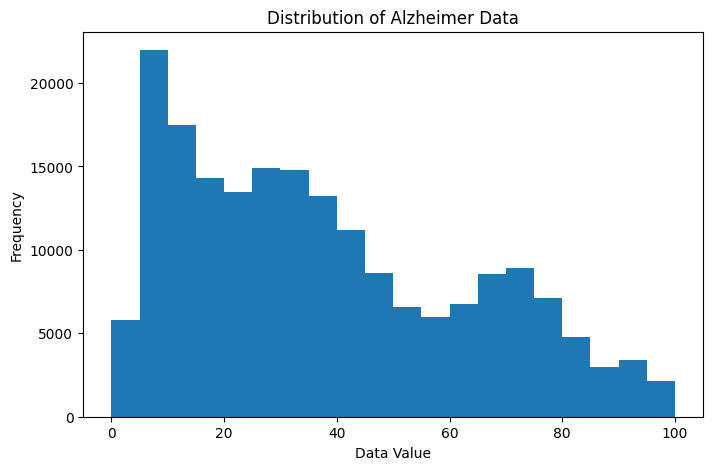

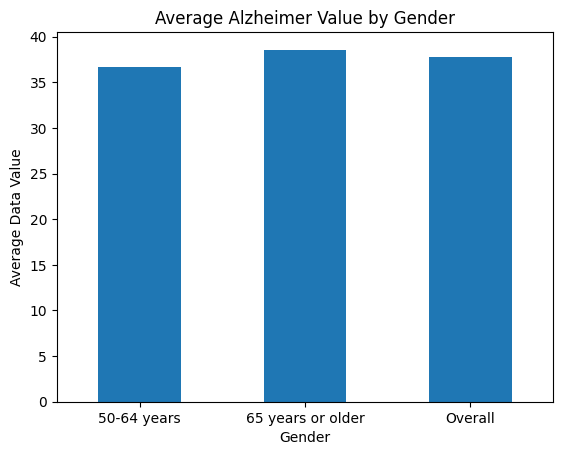

In [ ]:
#histogram
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))

plt.hist(df['Data_Value'].dropna(), bins=20)

plt.title('Distribution of Alzheimer Data')
plt.xlabel('Data Value')
plt.ylabel('Frequency')

plt.show()
gender_analysis = df.groupby('Stratification1')['Data_Value'].mean()
 #bar graph
gender_analysis.plot(kind='bar')

plt.title('Average Alzheimer Value by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Data Value')
plt.xticks(rotation=0)

plt.show()

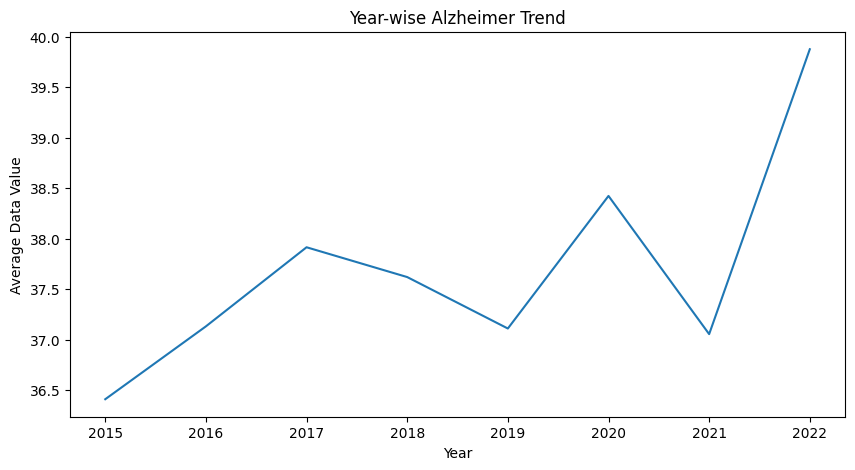

In [17]:
plt.figure(figsize=(10,5))

year_analysis = df.groupby('YearStart')['Data_Value'].mean()

plt.plot(year_analysis.index, year_analysis.values)

plt.title('Year-wise Alzheimer Trend')
plt.xlabel('Year')
plt.ylabel('Average Data Value')

plt.show()

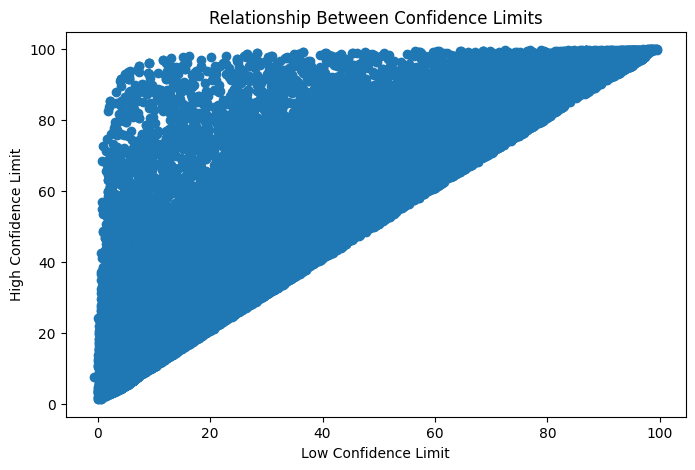

In [18]:
#scatter-plot 
plt.figure(figsize=(8,5))

plt.scatter(
    df['Low_Confidence_Limit'],
    df['High_Confidence_Limit']
)

plt.title('Relationship Between Confidence Limits')
plt.xlabel('Low Confidence Limit')
plt.ylabel('High Confidence Limit')

plt.show()

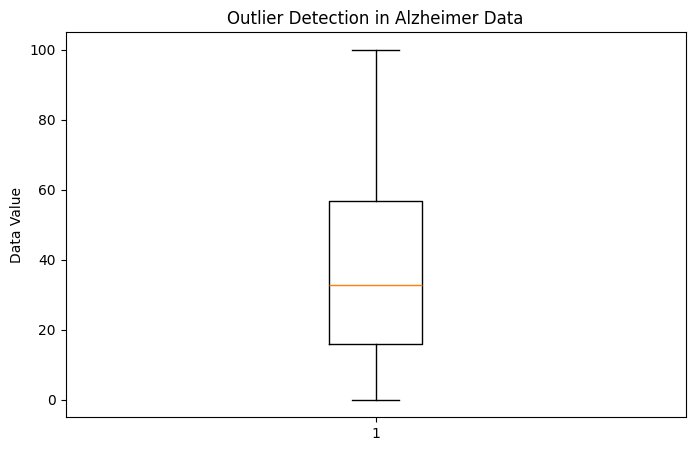

In [19]:
#box plot 
plt.figure(figsize=(8,5))

plt.boxplot(df['Data_Value'].dropna())

plt.title('Outlier Detection in Alzheimer Data')
plt.ylabel('Data Value')

plt.show()